## RNN: Thorcino ways

The aim of this notebook is to show how to train a classic RNN using this framework


In [ ]:
import numpy as np

N = 10
T = 5

def create_sequence(len: int, start: float, stop: float) -> np.ndarray:
    return np.linspace(start, stop, len)

def create_random_sequences(n: int, len:int, min_start: int=10, seed: float=777) -> np.ndarray:
    rng = np.random.default_rng(seed)
    sequences = []
    for _ in range(n):
        start = rng.integers(1, min_start, size=1)[0]
        stop = start * 3
        seq = create_sequence(len+1, start, stop)

        sequences.append(seq)

    return np.stack(sequences)

Train = create_random_sequences(N, T)
Train = Train.reshape(Train.shape[0], Train.shape[1], 1)
Test = create_random_sequences(N, T, min_start=7)
Test = Test.reshape(Train.shape[0], Train.shape[1], 1)

X_tr, Y_tr = Train[:, :-1], Train[:, 1:]
X_te, Y_te = Test[:, :-1], Test[:, 1:]

In [ ]:
"""Model architecture"""

from thorcino.activations import Identity
from thorcino.layers import Sequential, RNN
from thorcino.losses import MSELoss
from thorcino.optimizer import SGD
from thorcino.training.schedulers import CosineSchedule
from thorcino.training.trainer import Trainer 

EPOCHS = 80
IN_FEATURE = 1
OUT_FEATURE = 1
HIDDEN_UNITS = 2
MAX_LR, MIN_LR = 1e-4, 1e-6

model = Sequential(
    RNN(
        IN_FEATURE, 
        OUT_FEATURE, 
        HIDDEN_UNITS, 
        h_activation=Identity(), 
        o_activation=Identity()
    ),
)
model.save_graph("./images/arch.png", True)
model.save_graph("./images/forward.png", False, True)
model.save_graph("./images/backward.png", False, backward=True)

loss = MSELoss()
optimizer = SGD(model.parameters, MAX_LR)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(model, loss, optimizer, scheduler)

In [ ]:
"""Preprocessing"""

from thorcino.dataset.dataset import DataLoader, TensorDataset
from thorcino.tensor import Tensor

X_tr, Y_tr = Tensor(X_tr), Tensor(Y_tr)
dataset_tr = TensorDataset(X_tr, Y_tr)
loader_tr = DataLoader(dataset_tr, N)

X_te, Y_te = Tensor(X_te), Tensor(Y_te)
dataset_te = TensorDataset(X_te, Y_te)
loader_te = DataLoader(dataset_te, N)

In [ ]:
"""Training"""

EVAL_STEP = int(EPOCHS / 10)

train_losses, eval_losses = [], []
for e in range(EPOCHS):
    loss = trainer.train_epoch(loader_tr)
    train_losses.append(loss)

    if e%EVAL_STEP == 0:
        loss, _ = trainer.eval(loader_te)
        eval_losses.append(loss)

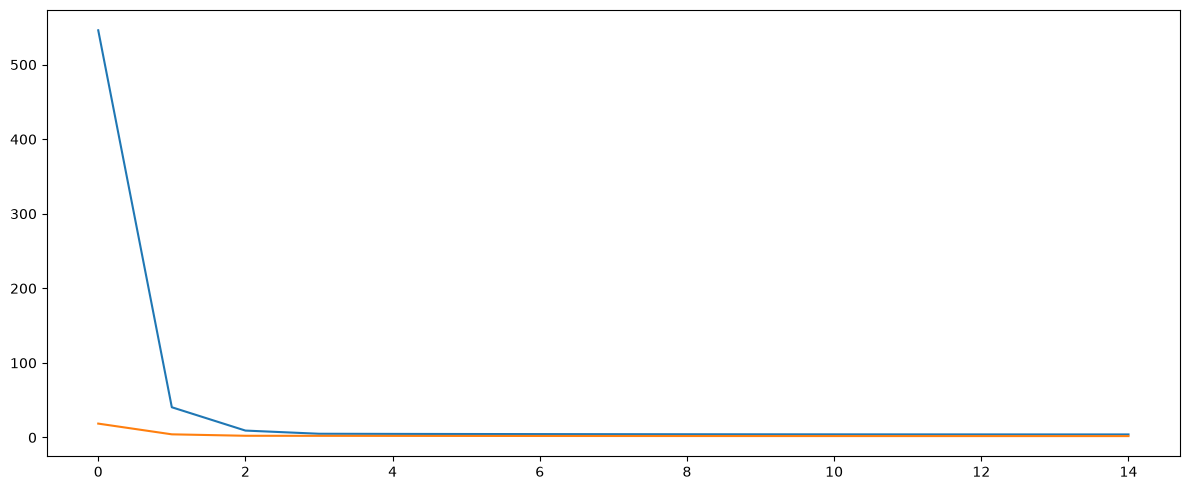

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

axs.plot(range(EPOCHS), train_losses)
axs.plot(range(0, EPOCHS, EVAL_STEP), eval_losses)

fig.tight_layout()
plt.show()

In [ ]:
"""Inference time"""

input, expected = X_te[2, :], Y_te[2, :]

model.eval()
preds = model(input).data.flatten()
expected = expected.data.flatten()

for exp, pred in zip(expected, preds):
    print(f'expected={exp}, pred={pred}')

expected=[4.2], pred=[[2.2894056]]
expected=[5.4], pred=[[3.1740584]]
expected=[6.6], pred=[[4.0587115]]
expected=[7.8], pred=[[4.9433637]]
expected=[9.], pred=[[5.8280168]]
